In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.document_loader import load_documents, split_documents

documents_path = PROJECT_ROOT / "data" / "documents"

documents = load_documents(str(documents_path))
chunks = split_documents(documents)

print("Number of documents:", len(documents))
print("Number of chunks:", len(chunks))

for i, chunk in enumerate(chunks[:3], start=1):
    print(f"\n--- Chunk {i} ---")
    print(chunk.page_content[:300])

Number of documents: 3
Number of chunks: 6

--- Chunk 1 ---
Deep learning is a branch of machine learning that uses neural networks with multiple layers to learn patterns from data.

A neural network contains interconnected units called neurons. These neurons process input data through layers and produce an output.

Deep learning is widely used in image reco

--- Chunk 2 ---
Convolutional neural networks (CNNs) are commonly used for image tasks. Transformer models are widely used for language tasks.

Deep learning models often require more data and computing power than simpler machine learning models.

--- Chunk 3 ---
Machine learning is a branch of artificial intelligence that allows computer systems to learn patterns from data.

Supervised learning uses labeled data. Common supervised learning tasks include classification and regression.

Unsupervised learning works with unlabeled data. Clustering is a common u


In [2]:
from src.embeddings import create_embeddings

embeddings = create_embeddings()

sample_texts = [
    "Machine learning allows computers to learn from data.",
    "Deep learning uses neural networks with multiple layers.",
    "I enjoy drinking a cup of tea."
]

vectors = embeddings.embed_documents(sample_texts)

print("Number of embeddings:", len(vectors))
print("Embedding dimensions:", len(vectors[0]))
print("\nFirst few values:")
print(vectors[0][:10])

e:\Mini-Knowledge-RAG-Agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3350.86it/s]


Number of embeddings: 3
Embedding dimensions: 384

First few values:
[-0.020890701562166214, 0.017379779368638992, 0.0723663792014122, 0.010321888141334057, 0.031034376472234726, -0.014285776764154434, -0.020717987790703773, -0.08304941654205322, 0.024357782676815987, 0.012648616917431355]


In [3]:
from src.vector_store import create_vector_store

vector_store = create_vector_store(chunks, embeddings)

question = "What is deep learning?"

results = vector_store.similarity_search(question, k=3)

for i, result in enumerate(results, start=1):
    print(f"\n--- Result {i} ---")
    print("Source:", result.metadata.get("source", "Unknown"))
    print(result.page_content[:300])


--- Result 1 ---
Source: e:\Mini-Knowledge-RAG-Agent\data\documents\deep_learning.txt
Deep learning is a branch of machine learning that uses neural networks with multiple layers to learn patterns from data.

A neural network contains interconnected units called neurons. These neurons process input data through layers and produce an output.

Deep learning is widely used in image reco

--- Result 2 ---
Source: e:\Mini-Knowledge-RAG-Agent\data\documents\deep_learning.txt
Convolutional neural networks (CNNs) are commonly used for image tasks. Transformer models are widely used for language tasks.

Deep learning models often require more data and computing power than simpler machine learning models.

--- Result 3 ---
Source: e:\Mini-Knowledge-RAG-Agent\data\documents\machine_learning.txt
Machine learning is a branch of artificial intelligence that allows computer systems to learn patterns from data.

Supervised learning uses labeled data. Common supervised learning tasks include classific

In [4]:
question = "What is deep learning?"

for k in [1, 2, 3, 5]:
    results = vector_store.similarity_search(question, k=k)

    print(f"\n{'=' * 40}")
    print(f"k = {k}")
    print("Retrieved chunks:", len(results))

    for result in results:
        print(
            "-",
            result.metadata.get("source", "Unknown"),
            "|",
            result.page_content[:100].replace("\n", " ")
        )


k = 1
Retrieved chunks: 1
- e:\Mini-Knowledge-RAG-Agent\data\documents\deep_learning.txt | Deep learning is a branch of machine learning that uses neural networks with multiple layers to lear

k = 2
Retrieved chunks: 2
- e:\Mini-Knowledge-RAG-Agent\data\documents\deep_learning.txt | Deep learning is a branch of machine learning that uses neural networks with multiple layers to lear
- e:\Mini-Knowledge-RAG-Agent\data\documents\deep_learning.txt | Convolutional neural networks (CNNs) are commonly used for image tasks. Transformer models are widel

k = 3
Retrieved chunks: 3
- e:\Mini-Knowledge-RAG-Agent\data\documents\deep_learning.txt | Deep learning is a branch of machine learning that uses neural networks with multiple layers to lear
- e:\Mini-Knowledge-RAG-Agent\data\documents\deep_learning.txt | Convolutional neural networks (CNNs) are commonly used for image tasks. Transformer models are widel
- e:\Mini-Knowledge-RAG-Agent\data\documents\machine_learning.txt | Machine learning is a

In [5]:
from dotenv import load_dotenv
from src.llm import create_llm

load_dotenv(PROJECT_ROOT / ".env")

llm = create_llm()

context = "\n\n".join(
    result.page_content
    for result in vector_store.similarity_search(
        "What is deep learning?",
        k=3
    )
)

question = "What is deep learning?"

prompt_1 = f"""
Answer this question using the context.

Context:
{context}

Question: {question}
"""

prompt_2 = f"""
Explain the answer in simple English.
Use only the context. If the answer is missing,
say that it is not available in the documents.

Context:
{context}

Question: {question}
"""

print("PROMPT 1 — Basic answer\n")
print(llm.invoke(prompt_1).content)

print("\nPROMPT 2 — Simple explanation\n")
print(llm.invoke(prompt_2).content)

PROMPT 1 — Basic answer

Deep learning is a subfield of machine learning that uses neural networks with many layers—often called “deep” neural networks—to automatically learn complex patterns from data. These networks consist of interconnected neurons that process input through successive layers, enabling the model to extract hierarchical features. Deep learning excels in tasks such as image recognition, speech recognition, natural language processing, and object detection, but typically requires large amounts of data and significant computational resources.

PROMPT 2 — Simple explanation

Deep learning is a type of machine learning that uses neural networks with many layers to learn patterns from data.


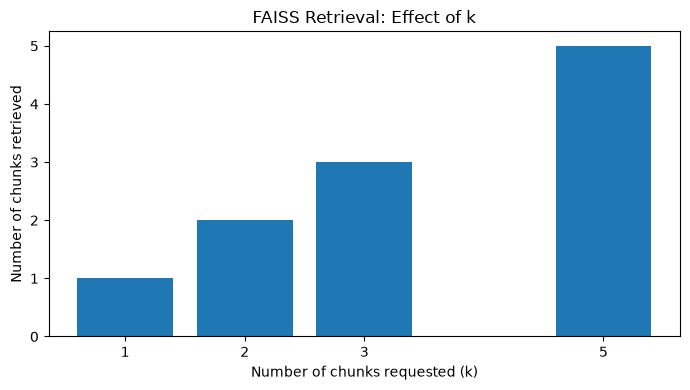

In [7]:
import matplotlib.pyplot as plt

k_values = [1, 2, 3, 5]
retrieved_counts = []

for k in k_values:
    results = vector_store.similarity_search(
        "What is deep learning?",
        k=k
    )
    retrieved_counts.append(len(results))

plt.figure(figsize=(7, 4))
plt.bar(k_values, retrieved_counts)
plt.xlabel("Number of chunks requested (k)")
plt.ylabel("Number of chunks retrieved")
plt.title("FAISS Retrieval: Effect of k")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

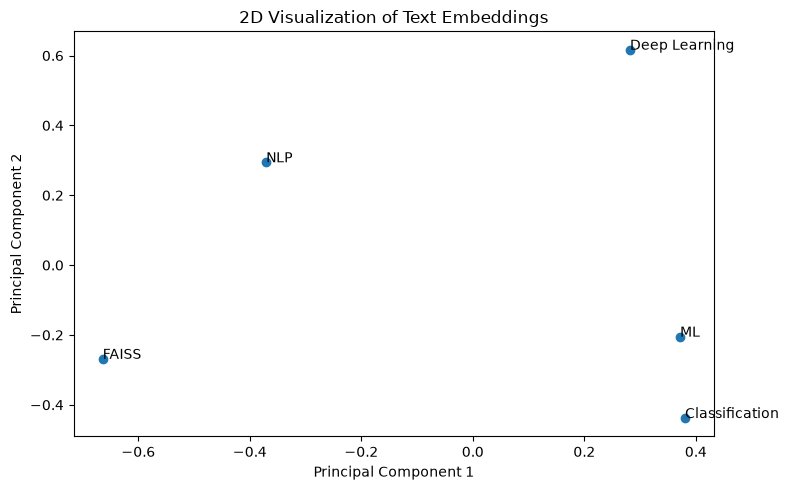

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

sample_texts = [
    "Machine learning learns patterns from data.",
    "Deep learning uses multi-layer neural networks.",
    "NLP helps computers understand human language.",
    "FAISS searches for similar document vectors.",
    "Classification predicts categories from examples."
]

sample_vectors = embeddings.embed_documents(sample_texts)

pca = PCA(n_components=2)
points = pca.fit_transform(sample_vectors)

plt.figure(figsize=(8, 5))
plt.scatter(points[:, 0], points[:, 1])

for i, label in enumerate(["ML", "Deep Learning", "NLP", "FAISS", "Classification"]):
    plt.annotate(label, (points[i, 0], points[i, 1]))

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D Visualization of Text Embeddings")
plt.tight_layout()
plt.show()